# Jasmin Experiments

Notebook orchestration only. Shared implementation lives in `src/`.

ROADMAP: 
Baseline PatchCore          0.40  (done)
+ multi-view fusion (done)         
+ DINOv2 backbone           0.41     (done)     
+ supervised patch MLP      0.79  (done)
+ MLP + DRAEM (done - too slow)
+ Test-Time Augmentation — easiest, do it first
No retraining. Average MLP predictions over 4-8 augmented versions of each test image (same D4/Klein-4 logic as training). Estimated +1-2%. Gets you to ~0.81.
+ FastFlow ensemble — highest expected gain
Normalizing flow on top of WideResNet50 features. Fully unsupervised, trains in ~30-45 min on T4 (~15 min locally). The key insight: MLP's weakness is unseen defect types (generalization gap 0.91→0.79). FastFlow catches any deviation from the normal feature distribution regardless of defect type — different failure mode, no whole-object elevation. Ensemble via global ranks like we tried with PatchCore. Estimated +2-3%.
+ Higher resolution (320×320)
Simple config change, retrain MLP. Fine-grained defects (cracks, small scratches) that are blurry at 224×224 become visible. The catch: ~2-3h retraining. Worth trying after TTA and FastFlow.

Semi-supervision improvements:
- Feature normalization — the MLP gets raw backbone features without normalizing by the training distribution. This is critical for MLP stability and performance. Should subtract the mean and divide by std of normal patch features before training.

- Focal loss instead of fixed pos_weight — with ~1% anomalous patches, a fixed weight is fragile. Focal loss dynamically focuses on hard examples.

- Data augmentation on anomalous patches — 235 examples is very few. Flipping/rotating anomalous patches during training effectively multiplies the anomaly dataset.

- The deepest issue — combining with PatchCore: The MLP sees raw features with no "normality reference". The most principled approach is to also feed PatchCore's k-NN distances as input features. The MLP then has both:
-- How far this patch is from the normal distribution (PatchCore)
-- What the patch looks like (backbone features)
- Hard negative mining — after first training pass, find the hardest normal patches (high MLP score but label=0) and oversample them in subsequent epochs.

The better architecture: instead of training from scratch, use PatchCore scores as starting point and train the MLP to calibrate/refine them using the labeled anomalies. Much less data needed.

First wideresnet patch MLP: 0.90 (on 20% test set)

Augmentation (4 rot + 2 rot for symmetric classes): 0.91

ensemble first: Pixel AP:    0.9036
Image AP:    0.7814
Pixel AUROC: 0.9952

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.evaluation import evaluate_predictions
from src.common.paths import resolve_path
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.validation import make_validation_split
from src.common.visualization import show_predictions
from src.methods import get_method_class

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("PyTorch:", torch.__version__)

CUDA available: True
Device: NVIDIA GeForce RTX 4060 Ti
PyTorch: 2.3.1


In [3]:
# supervised MLP (primary method)
config = load_config(ROOT / "configs/supervised_patch_mlp/jasmin_mlp.yaml")

set_seed(config.get("seed", 42))

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)
config["data"]["load_images"] = False

# --- Toggles ---
SAVE_FILE              = True
NO_BACKGROUND          = True
NO_BACKGROUND_TRAINING = True
VIEW_WISE              = True
MULTI_VIEW_FUSION      = True
MULTI_VIEW_CONSISTENCY = True
CONSISTENCY_ALPHA      = 0.5
ENSEMBLE               = False    # combine MLP + PatchCore predictions
ENSEMBLE_MLP_WEIGHT    = 0.9
TTA                    = True  # test-time augmentation (4x or 8x slower inference)
BG_DILATION            = 16
BG_THRESHOLD           = 0.20
BG_THRESHOLD_PER_CLASS = {
    "class_01": 0.40,
    "class_02": 0.30,
    "class_08": 0.40,
}

def get_bg_threshold(class_name, view_id=None):
    if view_id and (class_name, view_id) in BG_THRESHOLD_PER_CLASS:
        return BG_THRESHOLD_PER_CLASS[(class_name, view_id)]
    return BG_THRESHOLD_PER_CLASS.get(class_name, BG_THRESHOLD)

if NO_BACKGROUND_TRAINING:
    config["method"]["no_background"]          = True
    config["method"]["bg_threshold"]           = BG_THRESHOLD
    config["method"]["bg_dilation"]            = BG_DILATION
    config["method"]["bg_threshold_per_class"] = BG_THRESHOLD_PER_CLASS

if VIEW_WISE:
    config["method"]["view_wise"] = True

dm = SpacepressoDataModule(**config["data"])
train_good      = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test            = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})

DEV_CLASSES = None
if DEV_CLASSES:
    train_good      = [s for s in train_good      if s.class_name in DEV_CLASSES]
    train_anomalies = [s for s in train_anomalies if s.class_name in DEV_CLASSES]
    test            = [s for s in test            if s.class_name in DEV_CLASSES]
    print(f"Filtered to {DEV_CLASSES}")

VAL_ANOMALY_FRACTION = 0.0
import random as _rng
_rng.seed(config.get("seed", 42))
_shuffled = _rng.sample(train_anomalies, len(train_anomalies))
_n_val = max(1, int(len(_shuffled) * VAL_ANOMALY_FRACTION)) if VAL_ANOMALY_FRACTION > 0 else 0
train_anomalies_val = _shuffled[:_n_val]
train_anomalies_fit = _shuffled[_n_val:]
print(f"Anomaly split: {len(train_anomalies_fit)} fit / {len(train_anomalies_val)} val")


{'train_good': 19005, 'train_anomalies': 235, 'test': 5910}
Anomaly split: 235 fit / 0 val


## Background extraction

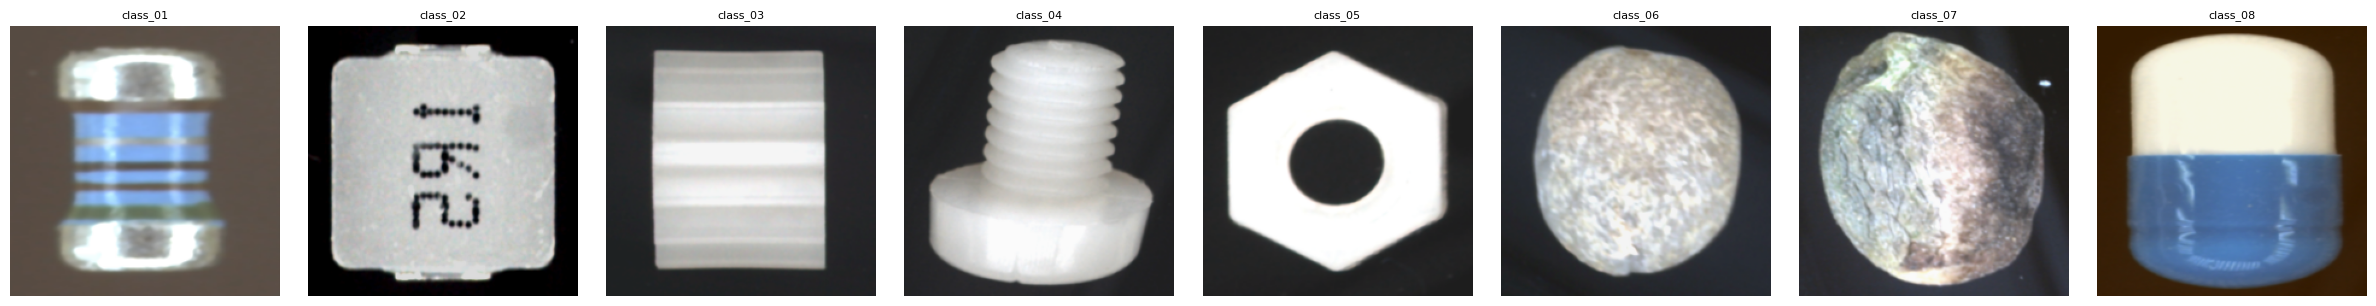

In [4]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np

classes = sorted({s.class_name for s in train_good})
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    sample = next(s for s in train_good if s.class_name == cls)
    img = np.array(PILImage.open(sample.image_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

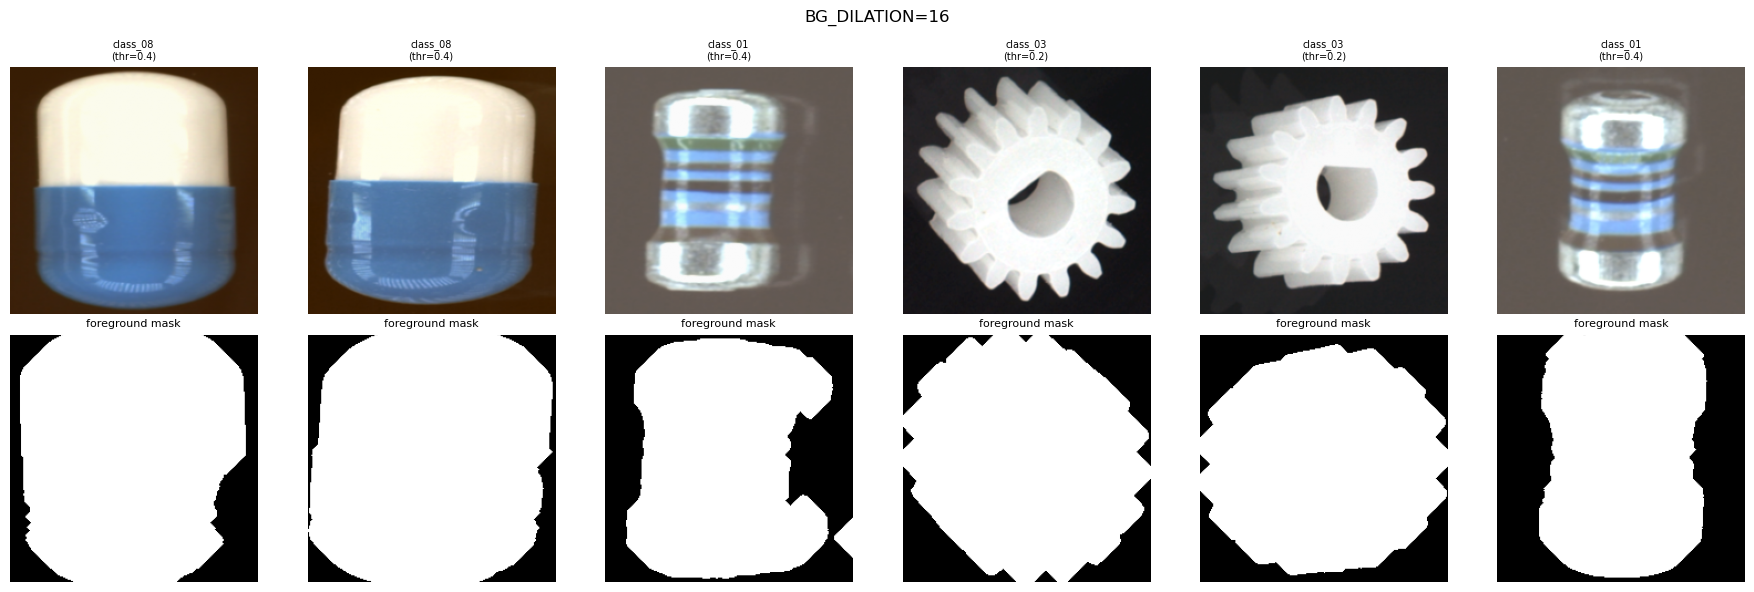

In [5]:
# Sanity check: visualize foreground masks on a few training images
if NO_BACKGROUND:
    import random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate

    def _preview_foreground_mask(image_np, threshold, dilation):
        gray = image_np.mean(axis=2)
        fg = binary_fill_holes(gray > threshold)
        if dilation > 0:
            fg = _bdilate(fg, iterations=dilation)
        return fg.astype(np.float32)

    samples = random.sample(train_good, 6)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col, sample in enumerate(samples):
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((config["data"]["image_size"], config["data"]["image_size"]))) / 255.0
        threshold = get_bg_threshold(sample.class_name)
        mask = _preview_foreground_mask(img, threshold, BG_DILATION)
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"{sample.class_name}\n(thr={threshold})", fontsize=7)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("foreground mask", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"BG_DILATION={BG_DILATION}")
    plt.tight_layout()
    plt.show()

## Training

c:\Users\PC\anaconda3\envs\adl_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Backbone: wide_resnet50_2 | grid=28×28 | feat_dim=1536

Fitting MLP for class_01: 2625 images (25 anomalous)


  Patch dataset: 22,000 patches | 2,000 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_01] MLP epoch 01/25 | loss=0.01291 | lr=9.96e-04
  [class_01] MLP epoch 02/25 | loss=0.00304 | lr=9.84e-04
  [class_01] MLP epoch 03/25 | loss=0.00167 | lr=9.65e-04
  [class_01] MLP epoch 04/25 | loss=0.00110 | lr=9.38e-04
  [class_01] MLP epoch 05/25 | loss=0.00079 | lr=9.05e-04
  [class_01] MLP epoch 06/25 | loss=0.00058 | lr=8.65e-04
  [class_01] MLP epoch 07/25 | loss=0.00052 | lr=8.19e-04
  [class_01] MLP epoch 08/25 | loss=0.00038 | lr=7.68e-04
  [class_01] MLP epoch 09/25 | loss=0.00032 | lr=7.13e-04
  [class_01] MLP epoch 10/25 | loss=0.00028 | lr=6.55e-04
  [class_01] MLP epoch 11/25 | loss=0.00022 | lr=5.94e-04
  [class_01] MLP epoch 12/25 | loss=0.00022 | lr=5.32e-04
  [class_01] MLP epoch 13/25 | loss=0.00021 | lr=4.69e-04
  [class_01] MLP epoch 14/25 | loss=0.00017 | lr=4.07e-04
  [class_01] MLP epoch 15/25 | loss=0.00014 | lr=3.46e-04
  [class_01] MLP epoch

  Patch dataset: 54,648 patches | 4,968 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_02] MLP epoch 01/25 | loss=0.00895 | lr=9.96e-04
  [class_02] MLP epoch 02/25 | loss=0.00166 | lr=9.84e-04
  [class_02] MLP epoch 03/25 | loss=0.00107 | lr=9.65e-04
  [class_02] MLP epoch 04/25 | loss=0.00082 | lr=9.38e-04
  [class_02] MLP epoch 05/25 | loss=0.00064 | lr=9.05e-04
  [class_02] MLP epoch 06/25 | loss=0.00051 | lr=8.65e-04
  [class_02] MLP epoch 07/25 | loss=0.00042 | lr=8.19e-04
  [class_02] MLP epoch 08/25 | loss=0.00036 | lr=7.68e-04
  [class_02] MLP epoch 09/25 | loss=0.00032 | lr=7.13e-04
  [class_02] MLP epoch 10/25 | loss=0.00026 | lr=6.55e-04
  [class_02] MLP epoch 11/25 | loss=0.00023 | lr=5.94e-04
  [class_02] MLP epoch 12/25 | loss=0.00022 | lr=5.32e-04
  [class_02] MLP epoch 13/25 | loss=0.00017 | lr=4.69e-04
  [class_02] MLP epoch 14/25 | loss=0.00015 | lr=4.07e-04
  [class_02] MLP epoch 15/25 | loss=0.00013 | lr=3.46e-04
  [class_02] MLP epoch

  Patch dataset: 11,352 patches | 1,032 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_03] MLP epoch 01/25 | loss=0.02174 | lr=9.96e-04
  [class_03] MLP epoch 02/25 | loss=0.00873 | lr=9.84e-04
  [class_03] MLP epoch 03/25 | loss=0.00390 | lr=9.65e-04
  [class_03] MLP epoch 04/25 | loss=0.00249 | lr=9.38e-04
  [class_03] MLP epoch 05/25 | loss=0.00189 | lr=9.05e-04
  [class_03] MLP epoch 06/25 | loss=0.00145 | lr=8.65e-04
  [class_03] MLP epoch 07/25 | loss=0.00105 | lr=8.19e-04
  [class_03] MLP epoch 08/25 | loss=0.00087 | lr=7.68e-04
  [class_03] MLP epoch 09/25 | loss=0.00078 | lr=7.13e-04
  [class_03] MLP epoch 10/25 | loss=0.00066 | lr=6.55e-04
  [class_03] MLP epoch 11/25 | loss=0.00055 | lr=5.94e-04
  [class_03] MLP epoch 12/25 | loss=0.00049 | lr=5.32e-04
  [class_03] MLP epoch 13/25 | loss=0.00042 | lr=4.69e-04
  [class_03] MLP epoch 14/25 | loss=0.00039 | lr=4.07e-04
  [class_03] MLP epoch 15/25 | loss=0.00036 | lr=3.46e-04
  [class_03] MLP epoch

...

  TTA [class_04] done: 745 images × 4 augments
TTA inference [class_05] (225 images)...


  TTA [class_05] done: 225 images × 8 augments
TTA inference [class_06] (1010 images)...


  TTA [class_06] done: 1010 images × 8 augments
TTA inference [class_07] (915 images)...


  TTA [class_07] done: 915 images × 8 augments
TTA inference [class_08] (960 images)...


  TTA [class_08] done: 960 images × 4 augments


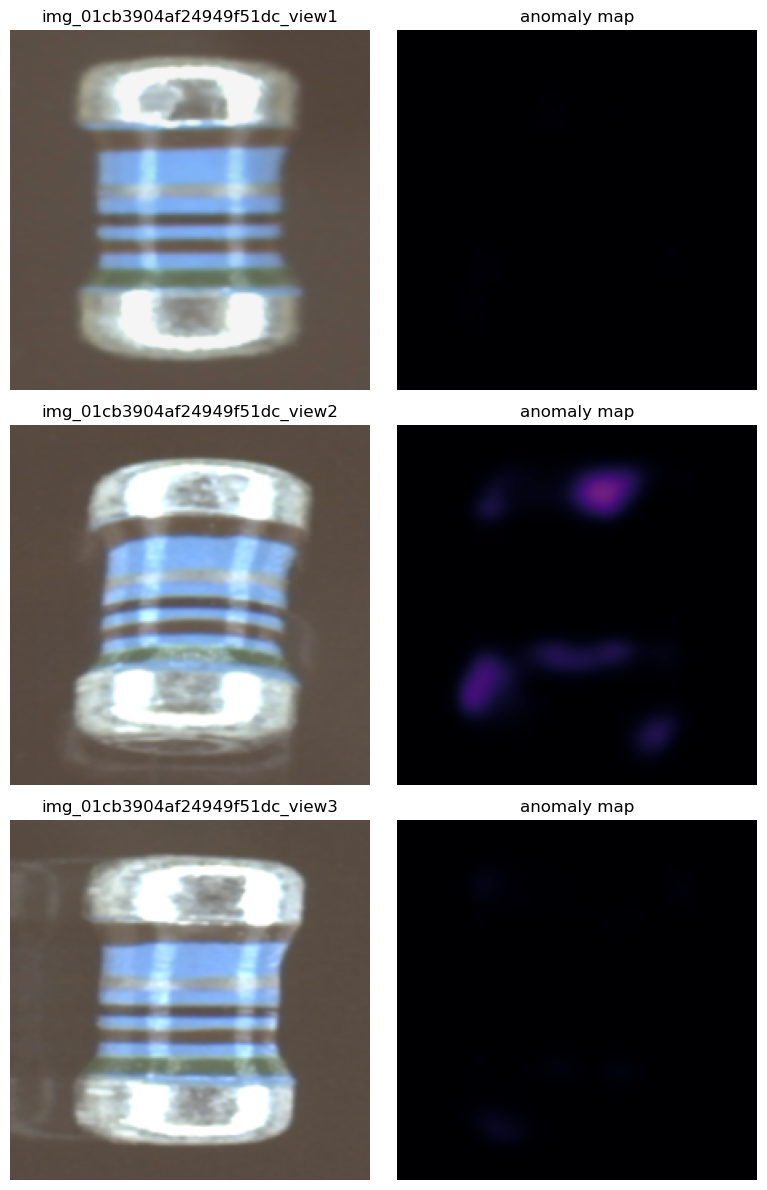

In [6]:
# --- Train supervised MLP ---
if train_good and test:
    Method = get_method_class(config["method"]["name"])
    runner = ExperimentRunner(Method(config), config)
    runner.fit(train_good + train_anomalies_fit)
    mlp_predictions = runner.method.predict(test, tta=TTA)
    show_predictions(test, mlp_predictions, n=3)
else:
    mlp_predictions = {}
    print("Dataset is empty or not found.")


In [7]:
# --- Train PatchCore (ensemble component) ---
if ENSEMBLE and train_good and test:
    pc_config = load_config(ROOT / "configs/patchcore_lite/jasmin_test.yaml")
    pc_config["data"]["root"]         = config["data"]["root"]
    pc_config["data"]["load_images"]  = False
    pc_config["method"]["no_background"]          = True
    pc_config["method"]["bg_threshold"]           = BG_THRESHOLD
    pc_config["method"]["bg_dilation"]            = BG_DILATION
    pc_config["method"]["bg_threshold_per_class"] = BG_THRESHOLD_PER_CLASS
    pc_config["method"]["view_wise"]              = VIEW_WISE

    pc_runner = ExperimentRunner(get_method_class("patchcore_lite")(pc_config), pc_config)
    pc_runner.fit(train_good)          # PatchCore only uses good images
    patchcore_predictions = pc_runner.predict(test)
    print(f"PatchCore predictions: {len(patchcore_predictions)} images")
else:
    patchcore_predictions = {}

In [8]:
# --- Ensemble: rank-based weighted average of MLP + PatchCore ---
import numpy as np
from scipy.stats import rankdata

def _global_ranks(preds_dict):
    """Global percentile ranks across ALL images — never per-image."""
    ids      = sorted(preds_dict.keys())
    flat_all = np.concatenate([preds_dict[iid].reshape(-1).astype(np.float32) for iid in ids])
    ranks    = (rankdata(flat_all, method="average") / len(flat_all)).astype(np.float32)
    n        = preds_dict[ids[0]].size
    return {iid: ranks[i * n : (i + 1) * n].reshape(preds_dict[iid].shape).astype(np.float16)
            for i, iid in enumerate(ids)}

if ENSEMBLE and patchcore_predictions and mlp_predictions:
    w_mlp = ENSEMBLE_MLP_WEIGHT
    w_pc  = 1.0 - w_mlp
    print("Computing global ranks...")
    mlp_ranked = _global_ranks(mlp_predictions)
    pc_ranked  = _global_ranks(patchcore_predictions)
    predictions = {
        iid: np.clip(
            w_mlp * mlp_ranked[iid].astype(np.float32) +
            w_pc  * pc_ranked[iid].astype(np.float32),
            0.0, 1.0
        ).astype(np.float16)
        for iid in mlp_predictions
    }
    print(f"Ensemble (rank-based): {w_mlp:.0%} MLP + {w_pc:.0%} PatchCore -> {len(predictions)} predictions")
else:
    predictions = mlp_predictions
    print(f'MLP{"(TTA)" if TTA else ""}: {len(predictions)} images')


MLP(TTA): 5910 images


In [9]:
#runner.method.plot_training_history()

In [10]:
# Background suppression: zero out outer black background in each prediction map
if NO_BACKGROUND and predictions:
    from PIL import Image as PILImage
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
    import numpy as np

    image_size = config["data"]["image_size"]
    id_to_sample = {s.image_id: s for s in test}

    for img_id, pred in predictions.items():
        sample = id_to_sample[img_id]
        threshold = get_bg_threshold(sample.class_name)
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
        fg = binary_fill_holes(img.mean(axis=2) > threshold)
        if BG_DILATION > 0:
            fg = _bdilate(fg, iterations=BG_DILATION)
        predictions[img_id] = pred * fg.astype(np.float32)

    print("Background suppression applied.")

Background suppression applied.


In [11]:
import numpy as np
from collections import defaultdict

# Build sample→views map from test set
sample_to_views = defaultdict(list)
for s in test:
    sample_to_views[s.sample_id].append(s.image_id)

# --- Multi-view fusion: propagate max score across all 5 views ---
if MULTI_VIEW_FUSION and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        maps = [predictions[iid] for iid in image_ids if iid in predictions]
        if not maps: continue
        sample_max = max(float(m.max()) for m in maps)
        for iid in image_ids:
            if iid not in predictions: continue
            view_max = float(predictions[iid].max())
            if view_max < sample_max - 1e-6:
                scale = sample_max / max(view_max, 1e-6)
                predictions[iid] = np.clip(predictions[iid] * scale, 0.0, 1.0).astype(predictions[iid].dtype)
                n_boosted += 1
    print(f"Multi-view fusion: {n_boosted} views boosted out of {len(predictions)} total")

# --- Multi-view consistency: boost samples where views strongly disagree ---
if MULTI_VIEW_CONSISTENCY and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        present = [iid for iid in image_ids if iid in predictions]
        if len(present) < 2: continue
        scores = [float(predictions[iid].max()) for iid in present]
        s_max, s_mean = max(scores), float(np.mean(scores))
        if s_mean < 1e-6: continue
        boost = 1.0 + CONSISTENCY_ALPHA * (s_max - s_mean) / (s_max + 1e-6)
        for iid in present:
            predictions[iid] = np.clip(predictions[iid] * boost, 0.0, 1.0).astype(predictions[iid].dtype)
            n_boosted += 1
    print(f"Multi-view consistency: boost applied to {n_boosted} views (alpha={CONSISTENCY_ALPHA})")

Multi-view fusion: 4500 views boosted out of 5910 total
Multi-view consistency: boost applied to 5910 views (alpha=0.5)


## Validation + File saving

In [12]:
# Cross-view feature infrastructure (used by the supervised patch MLP in the next roadmap step)
# Builds a lookup: sample_id → {view_id: image_id} for both train and test sets
from collections import defaultdict

def build_sample_view_index(samples):
    """Returns {sample_id: {view_id: image_id}} for quick cross-view lookup."""
    index = defaultdict(dict)
    for s in samples:
        index[s.sample_id][s.view_id] = s.image_id
    return dict(index)

train_sample_index = build_sample_view_index(train_good + train_anomalies)
test_sample_index  = build_sample_view_index(test)

# Sanity check: how many samples have all 5 views?
full_samples = sum(1 for v in test_sample_index.values() if len(v) == 5)
print(f"Test samples with all 5 views: {full_samples} / {len(test_sample_index)}")
print(f"Train samples with all 5 views: {sum(1 for v in train_sample_index.values() if len(v) == 5)} / {len(train_sample_index)}")

Test samples with all 5 views: 1182 / 1182
Train samples with all 5 views: 3848 / 3848


In [13]:
# Validation: mirrors the full submission pipeline (ensemble + bg suppression + multi-view)
if predictions:
    import random as _random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from collections import defaultdict
    from src.common.evaluation import load_sample_mask

    N_GOOD_VAL = 200
    good_sample = _random.sample(train_good, min(N_GOOD_VAL, len(train_good)))
    val_samples = train_anomalies_val + good_sample

    # Step 1: MLP predictions
    mlp_val = runner.predict(val_samples)

    # Step 2: ensemble with PatchCore
    if ENSEMBLE and patchcore_predictions:
        pc_val    = pc_runner.predict(val_samples)
        mlp_val_r = _global_ranks(mlp_val)
        pc_val_r  = _global_ranks(pc_val)
        w_mlp = ENSEMBLE_MLP_WEIGHT
        val_predictions = {
            iid: np.clip(
                w_mlp * mlp_val_r[iid].astype(np.float32) +
                (1 - w_mlp) * pc_val_r[iid].astype(np.float32),
                0.0, 1.0
            ).astype(np.float16)
            for iid in mlp_val
        }
    else:
        val_predictions = mlp_val

    # Step 3: background suppression
    if NO_BACKGROUND:
        from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
        id_to_sample = {s.image_id: s for s in val_samples}
        image_size   = config["data"]["image_size"]
        for img_id, pred in val_predictions.items():
            s   = id_to_sample[img_id]
            thr = get_bg_threshold(s.class_name)
            img = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
            fg  = binary_fill_holes(img.mean(axis=2) > thr)
            if BG_DILATION > 0:
                fg = _bdilate(fg, iterations=BG_DILATION)
            val_predictions[img_id] = pred * fg.astype(np.float32)

    # Step 4: multi-view fusion + consistency
    val_sample_to_views = defaultdict(list)
    for s in val_samples:
        val_sample_to_views[s.sample_id].append(s.image_id)

    if MULTI_VIEW_FUSION:
        for image_ids in val_sample_to_views.values():
            maps = [val_predictions[iid] for iid in image_ids if iid in val_predictions]
            if not maps: continue
            sample_max = max(float(m.max()) for m in maps)
            for iid in image_ids:
                if iid not in val_predictions: continue
                view_max = float(val_predictions[iid].max())
                if view_max < sample_max - 1e-6:
                    val_predictions[iid] = np.clip(
                        val_predictions[iid] * (sample_max / max(view_max, 1e-6)), 0.0, 1.0
                    ).astype(val_predictions[iid].dtype)

    if MULTI_VIEW_CONSISTENCY:
        for image_ids in val_sample_to_views.values():
            present = [iid for iid in image_ids if iid in val_predictions]
            if len(present) < 2: continue
            scores = [float(val_predictions[iid].max()) for iid in present]
            s_max, s_mean = max(scores), float(np.mean(scores))
            if s_mean < 1e-6: continue
            boost = 1.0 + CONSISTENCY_ALPHA * (s_max - s_mean) / (s_max + 1e-6)
            for iid in present:
                val_predictions[iid] = np.clip(
                    val_predictions[iid] * boost, 0.0, 1.0
                ).astype(val_predictions[iid].dtype)

    # Evaluate
    metrics = evaluate_predictions(val_samples, val_predictions).as_dict()
    mode = f"Ensemble {int(ENSEMBLE_MLP_WEIGHT*100)}/{int((1-ENSEMBLE_MLP_WEIGHT)*100)}" if ENSEMBLE else "MLP only"
    print(f"[{mode}] Evaluated on {len(train_anomalies_val)} anomalies + {len(good_sample)} good images")
    print(f"Pixel AP:    {metrics['pixel_ap']:.4f}")
    print(f"Image AP:    {metrics['image_ap']:.4f}")
    auroc = metrics['pixel_auroc']
    print(f"Pixel AUROC: {auroc:.4f}" if auroc is not None else "Pixel AUROC: N/A (no anomalies in val set)")

    # Visualise
    image_size = config["data"]["image_size"]
    grouped = {}
    for s in train_anomalies_val:
        grouped.setdefault(s.class_name, []).append(s)

    if grouped:
        n_classes = len(grouped)
        fig, axes = plt.subplots(n_classes, 6, figsize=(18, 3 * n_classes), squeeze=False)
        for row, (cls, samples) in enumerate(sorted(grouped.items())):
            picks = _random.sample(samples, min(2, len(samples)))
            for col_offset, s in enumerate(picks):
                img  = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size)))
                gt   = load_sample_mask(s, (image_size, image_size))
                pred = val_predictions[s.image_id]
                c = col_offset * 3
                axes[row, c].imshow(img);           axes[row, c].axis("off")
                axes[row, c].set_title(f"{cls}" if col_offset == 0 else "", fontsize=7)
                axes[row, c+1].imshow(gt,   cmap="hot", vmin=0, vmax=1); axes[row, c+1].axis("off")
                axes[row, c+1].set_title("ground truth" if row == 0 else "", fontsize=7)
                axes[row, c+2].imshow(pred, cmap="hot", vmin=0, vmax=1); axes[row, c+2].axis("off")
                axes[row, c+2].set_title("prediction" if row == 0 else "", fontsize=7)
        plt.suptitle("Validation — full ensemble pipeline", fontsize=9)
        plt.tight_layout()
        plt.show()

[MLP only] Evaluated on 0 anomalies + 200 good images
Pixel AP:    0.0000
Image AP:    0.0000
Pixel AUROC: N/A (no anomalies in val set)


In [14]:
if predictions and SAVE_FILE:
    import zipfile, random
    from datetime import datetime
    from src.common.submission import _prepare_prediction_map
    from src.common.q8rle import float_matrix_to_q8rle, q8rle_to_float_matrix

    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_path = resolve_path(config["submission"]["output_path"], ROOT)
    parts = []
    if TTA:     parts.append("tta")
    if ENSEMBLE: parts.append(f"ens{int(ENSEMBLE_MLP_WEIGHT*100)}mlp{int((1-ENSEMBLE_MLP_WEIGHT)*100)}pc")
    stem = "_".join(parts) + f"_{timestamp}" if parts else f"{base_path.stem}_{timestamp}"
    zip_path = base_path.parent / f"{stem}.zip"
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(f"{stem}.csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, f"Shape mismatch for {img_id}"

    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")


Saved: C:\Users\PC\Desktop\GITHUB REPO\Spacespresso\submissions\jasmin\tta_20260514_002850.zip (38.5 MB)
